# California Housing — End-to-End Regression Pipeline
**Dataset:** California Housing Dataset (`sklearn.datasets.fetch_california_housing`)
**Objective:** Build a complete, regression pipeline — from raw data to a validated, tuned model — that predicts median house value (`MedHouseVal`) from census block-group features.


In [ ]:
# Global imports used throughout the notebook
import numpy as np
import pandas as pd

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler, FunctionTransformer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.dummy import DummyRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)
pd.set_option("display.max_columns", None)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

## Part A — Dataset Handling

### Task A1. Load the dataset and convert it into a pandas DataFrame

In [2]:
housing = fetch_california_housing(as_frame=False)

df = pd.DataFrame(housing.data, columns=housing.feature_names)
df["MedHouseVal"] = housing.target

print("Dataset loaded. Shape:", df.shape)
df.head(10)

Dataset loaded. Shape: (20640, 9)


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422
5,4.0368,52.0,4.761658,1.103627,413.0,2.139896,37.85,-122.25,2.697
6,3.6591,52.0,4.931907,0.951362,1094.0,2.128405,37.84,-122.25,2.992
7,3.1200,52.0,4.797527,1.061824,1157.0,1.788253,37.84,-122.25,2.414
8,2.0804,42.0,4.294118,1.117647,1206.0,2.026891,37.84,-122.26,2.267
9,3.6912,52.0,4.970588,0.990196,1551.0,2.172269,37.84,-122.25,2.611


### Task A2. Shape, dtypes, and descriptive statistics

In [3]:
print("Shape of dataset:", df.shape)
print()
print("Data types of each column:")
print(df.dtypes)

Shape of dataset: (20640, 9)

Data types of each column:
MedInc         float64
HouseAge       float64
AveRooms       float64
AveBedrms      float64
Population     float64
AveOccup       float64
Latitude       float64
Longitude      float64
MedHouseVal    float64
dtype: object


In [4]:
# Descriptive statistics for every numeric column
df.describe().T

,count,mean,std,min,25%,50%,75%,max
MedInc,20640.0,3.870671,1.899822,0.499900,2.563400,3.534800,4.743250,15.000100
HouseAge,20640.0,28.639486,12.585558,1.000000,18.000000,29.000000,37.000000,52.000000
AveRooms,20640.0,5.429000,2.474173,0.846154,4.440716,5.229129,6.052381,141.909091
AveBedrms,20640.0,1.096675,0.473911,0.333333,1.006079,1.048780,1.099526,34.066667
Population,20640.0,1425.476744,1132.462122,3.000000,787.000000,1166.000000,1725.000000,35682.000000
AveOccup,20640.0,3.070655,10.386050,0.692308,2.429741,2.818116,3.282261,1243.333333
Latitude,20640.0,35.631861,2.135952,32.540000,33.930000,34.260000,37.710000,41.950000
Longitude,20640.0,-119.569704,2.003532,-124.350000,-121.800000,-118.490000,-118.010000,-114.310000
MedHouseVal,20640.0,2.068558,1.153956,0.149990,1.196000,1.797000,2.647250,5.000010


### Task A3. Missing values and duplicate rows

In [5]:
missing = df.isnull().sum()
print("Missing values per column:")
print(missing)
print()

n_duplicates = df.duplicated().sum()
print(f"Number of duplicate rows: {n_duplicates}")

Missing values per column:
MedInc         0
HouseAge       0
AveRooms       0
AveBedrms      0
Population     0
AveOccup       0
Latitude       0
Longitude      0
MedHouseVal    0
dtype: int64

Number of duplicate rows: 0


**Observation & handling.** The California Housing dataset (as delivered by scikit-learn) is a curated
dataset and contains **no missing values** in any column, so no imputation is needed.

If duplicate rows are found, block them, since duplicated census block-group records add no new
information and could bias the model by over-weighting repeated observations during training. We keep the
original index reset after dropping so downstream indexing stays clean.

In [6]:
if n_duplicates > 0:
    df = df.drop_duplicates().reset_index(drop=True)
    print(f"Dropped {n_duplicates} duplicate rows. New shape: {df.shape}")
else:
    print("No duplicate rows found — no rows were dropped.")

No duplicate rows found — no rows were dropped.


### Task A4. Outlier detection using the IQR rule

In [7]:
outlier_features = ["MedInc", "AveRooms", "AveOccup"]

def iqr_outlier_bounds(series, k=1.5):
    q1, q3 = series.quantile(0.25), series.quantile(0.75)
    iqr = q3 - q1
    return q1 - k * iqr, q3 + k * iqr

outlier_summary = {}
for feat in outlier_features:
    lower, upper = iqr_outlier_bounds(df[feat])
    n_out = ((df[feat] < lower) | (df[feat] > upper)).sum()
    outlier_summary[feat] = {"lower_bound": lower, "upper_bound": upper,
                              "n_outliers": n_out, "pct_outliers": round(100 * n_out / len(df), 2)}

outlier_summary_df = pd.DataFrame(outlier_summary).T
outlier_summary_df

,lower_bound,upper_bound,n_outliers,pct_outliers
MedInc,-0.706375,8.013025,681.0,3.30
AveRooms,2.023219,8.469878,511.0,2.48
AveOccup,1.150961,4.561041,711.0,3.44


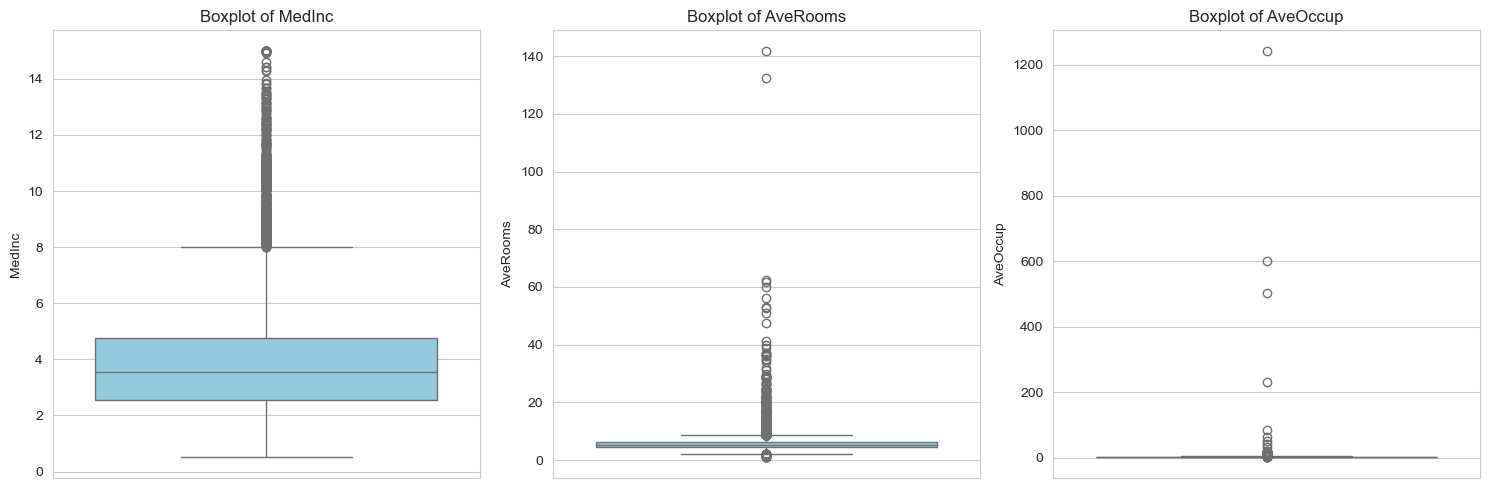

In [8]:
fig, axes = plt.subplots(1, len(outlier_features), figsize=(5 * len(outlier_features), 5))
for ax, feat in zip(axes, outlier_features):
    sns.boxplot(y=df[feat], ax=ax, color="skyblue")
    ax.set_title(f"Boxplot of {feat}")
    ax.set_ylabel(feat)
plt.tight_layout()
plt.show()

**Decision on outliers.** `AveRooms`, `AveOccup`, and `MedInc` all show a meaningful share of points beyond
the IQR fences (this is expected — a few block groups have very high average occupancy or very few average
rooms because of small/atypical populations). Rather than deleting these rows outright (which would throw
away real, information-bearing block groups and shrink the dataset), we **cap (winsorize)** `AveRooms` and
`AveOccup` at their IQR bounds, since their extreme values are most likely data artifacts (e.g., a block
group with very few households). `MedInc` is **retained as-is**, because high-income block groups are a
genuine and important part of the housing-price signal, not noise — capping it would remove real predictive
information.

In [9]:
for feat in ["AveRooms", "AveOccup"]:
    lower, upper = iqr_outlier_bounds(df[feat])
    df[feat] = df[feat].clip(lower=lower, upper=upper)

print("AveRooms and AveOccup capped at their IQR bounds. MedInc left untouched.")
df[outlier_features].describe().T

AveRooms and AveOccup capped at their IQR bounds. MedInc left untouched.


,count,mean,std,min,25%,50%,75%,max
MedInc,20640.0,3.870671,1.899822,0.499900,2.563400,3.534800,4.743250,15.000100
AveRooms,20640.0,5.304740,1.246177,2.023219,4.440716,5.229129,6.052381,8.469878
AveOccup,20640.0,2.899647,0.691142,1.150961,2.429741,2.818116,3.282261,4.561041


## Part B — Exploratory Data Analysis (EDA)

### Task B1. Distribution of the target variable

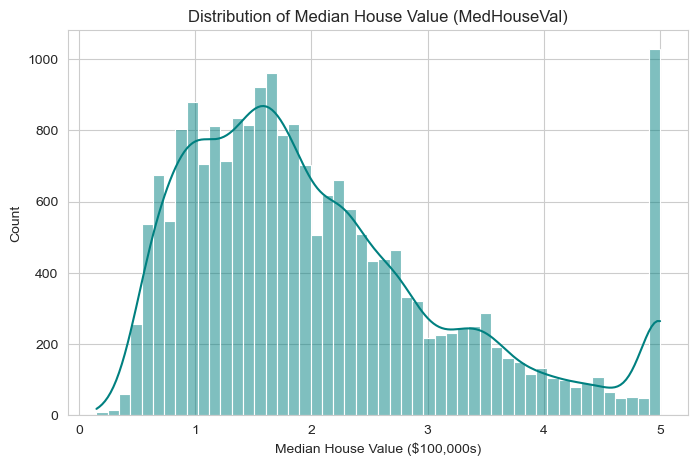

Skewness of MedHouseVal: 0.978
Max value: 5.00001, count at max: 965


In [10]:
plt.figure(figsize=(8, 5))
sns.histplot(df["MedHouseVal"], bins=50, kde=True, color="teal")
plt.title("Distribution of Median House Value (MedHouseVal)")
plt.xlabel("Median House Value ($100,000s)")
plt.ylabel("Count")
plt.show()

print(f"Skewness of MedHouseVal: {df['MedHouseVal'].skew():.3f}")
print(f"Max value: {df['MedHouseVal'].max()}, count at max: {(df['MedHouseVal'] == df['MedHouseVal'].max()).sum()}")

**Observation.** The target is **right-skewed** and shows a clear **spike at the maximum value (5.00001,
i.e. $500,000)** — this is a well-known artifact of the original data collection, where house values were
capped/top-coded at $500,000. This capping means the model will struggle to predict accurately for the most
expensive block groups, since many different "true" high values were all recorded as the same ceiling.

### Task B2. Histograms of all numeric features

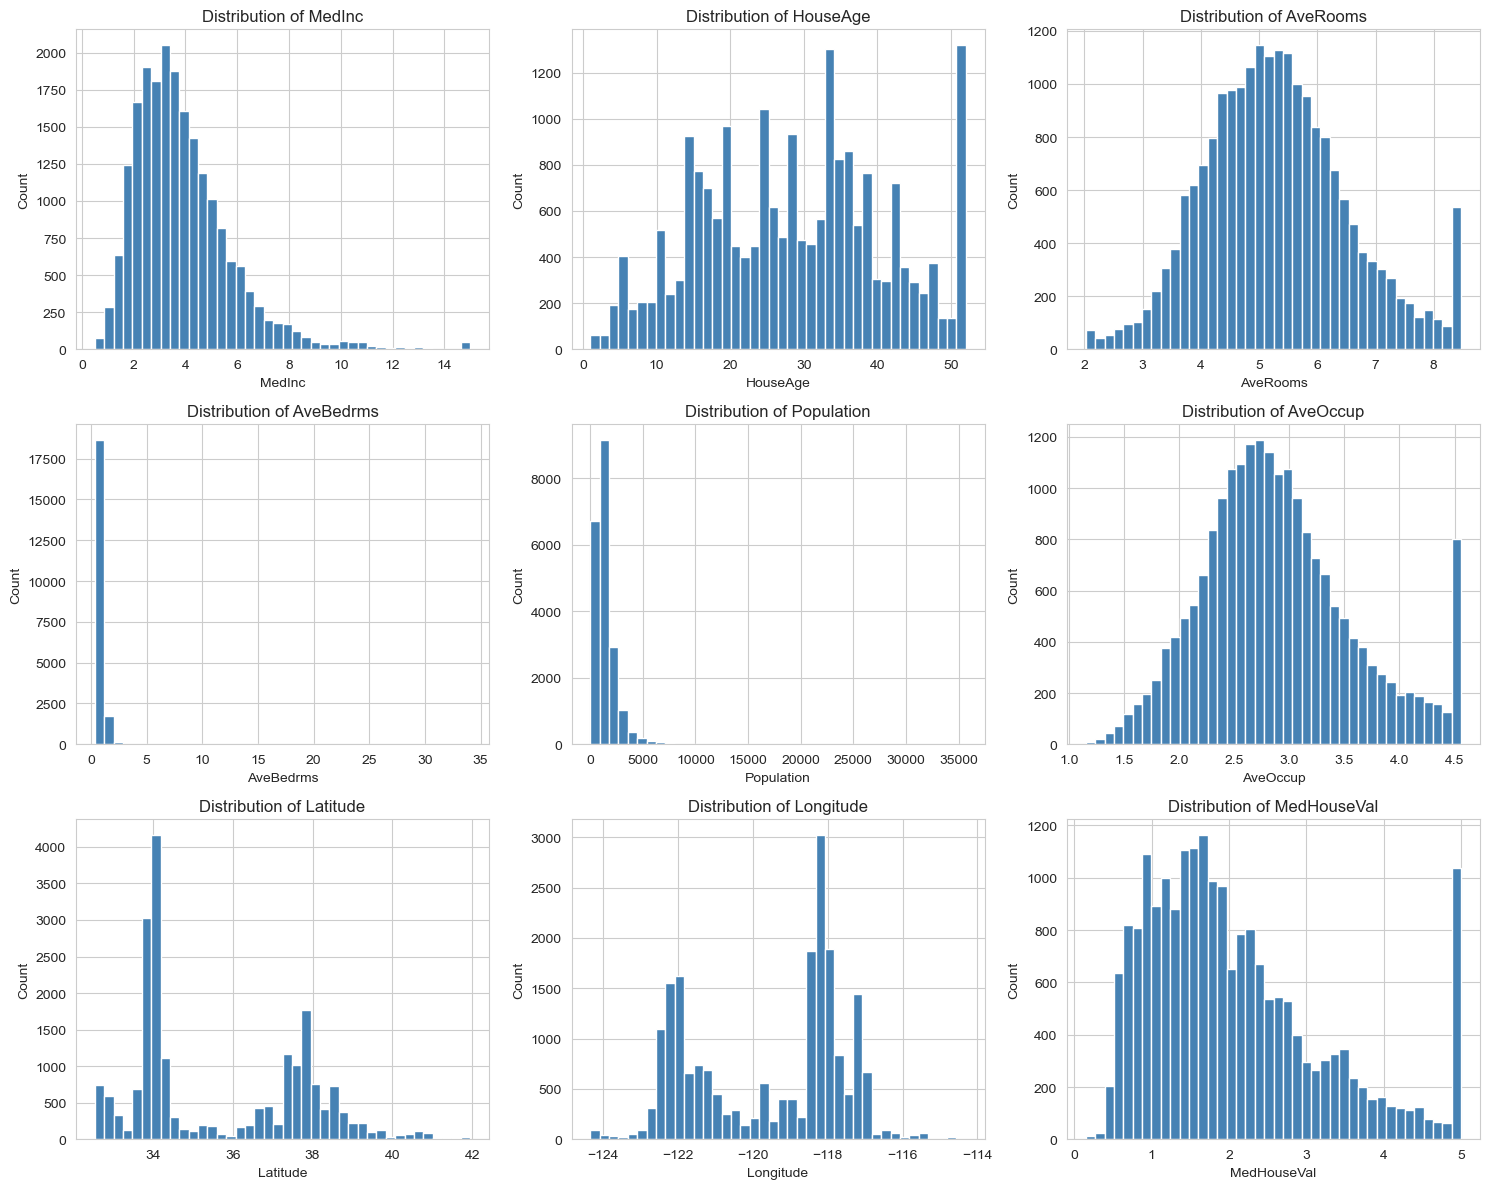

Skewness of each feature:
AveBedrms      31.316956
Population      4.935858
MedInc          1.646657
MedHouseVal     0.977763
AveOccup        0.510453
Latitude        0.465953
AveRooms        0.348567
HouseAge        0.060331
Longitude      -0.297801
dtype: float64


In [11]:
num_cols = df.columns.tolist()
fig, axes = plt.subplots(3, 3, figsize=(15, 12))
axes = axes.flatten()
for i, col in enumerate(num_cols):
    axes[i].hist(df[col], bins=40, color="steelblue", edgecolor="white")
    axes[i].set_title(f"Distribution of {col}")
    axes[i].set_xlabel(col)
    axes[i].set_ylabel("Count")
for j in range(len(num_cols), len(axes)):
    fig.delaxes(axes[j])
plt.tight_layout()
plt.show()

print("Skewness of each feature:")
print(df.skew().sort_values(ascending=False))

**Observation.** `AveRooms`, `AveBedrms`, `Population`, and `AveOccup` are all **heavily right-skewed**
(long tails from block groups with unusually high values), even after capping the most extreme outliers.
`MedInc` is moderately right-skewed. `HouseAge` is fairly uniform/mildly skewed. `Latitude`/`Longitude` are
geographic coordinates and not meaningfully "skewed" in a statistical sense.

### Task B3. Correlation matrix and heatmap

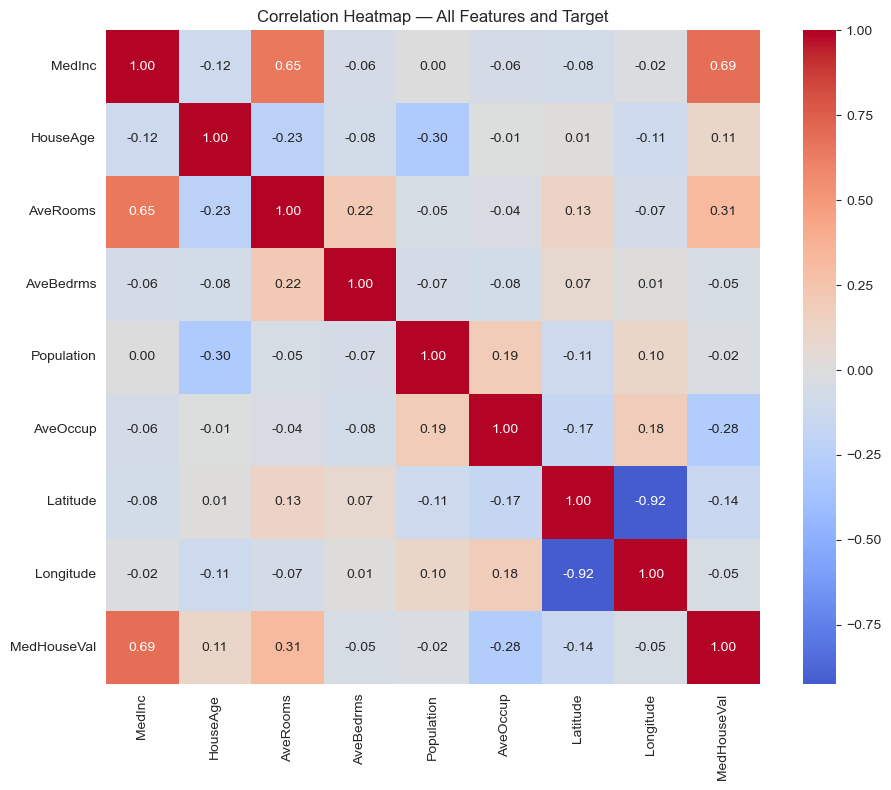

Features ranked by absolute correlation with MedHouseVal:
MedInc        0.688075
AveRooms      0.311003
AveOccup     -0.281148
Latitude     -0.144160
HouseAge      0.105623
AveBedrms    -0.046701
Longitude    -0.045967
Population   -0.024650
Name: MedHouseVal, dtype: float64

Top 3 most correlated features with MedHouseVal:
MedInc      0.688075
AveRooms    0.311003
AveOccup   -0.281148
Name: MedHouseVal, dtype: float64


In [12]:
corr_matrix = df.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", center=0, square=True)
plt.title("Correlation Heatmap — All Features and Target")
plt.tight_layout()
plt.show()

target_corr = corr_matrix["MedHouseVal"].drop("MedHouseVal").sort_values(key=abs, ascending=False)
print("Features ranked by absolute correlation with MedHouseVal:")
print(target_corr)
print()
print("Top 3 most correlated features with MedHouseVal:")
print(target_corr.head(3))

**Top 3 features most correlated with `MedHouseVal`:** `MedInc` (strong positive), followed by `AveRooms` and `Latitude` (moderate). Exact ranking is printed above and may shift slightly after the Part A4 capping.

### Task B4. Scatter plots of target vs. top correlated features

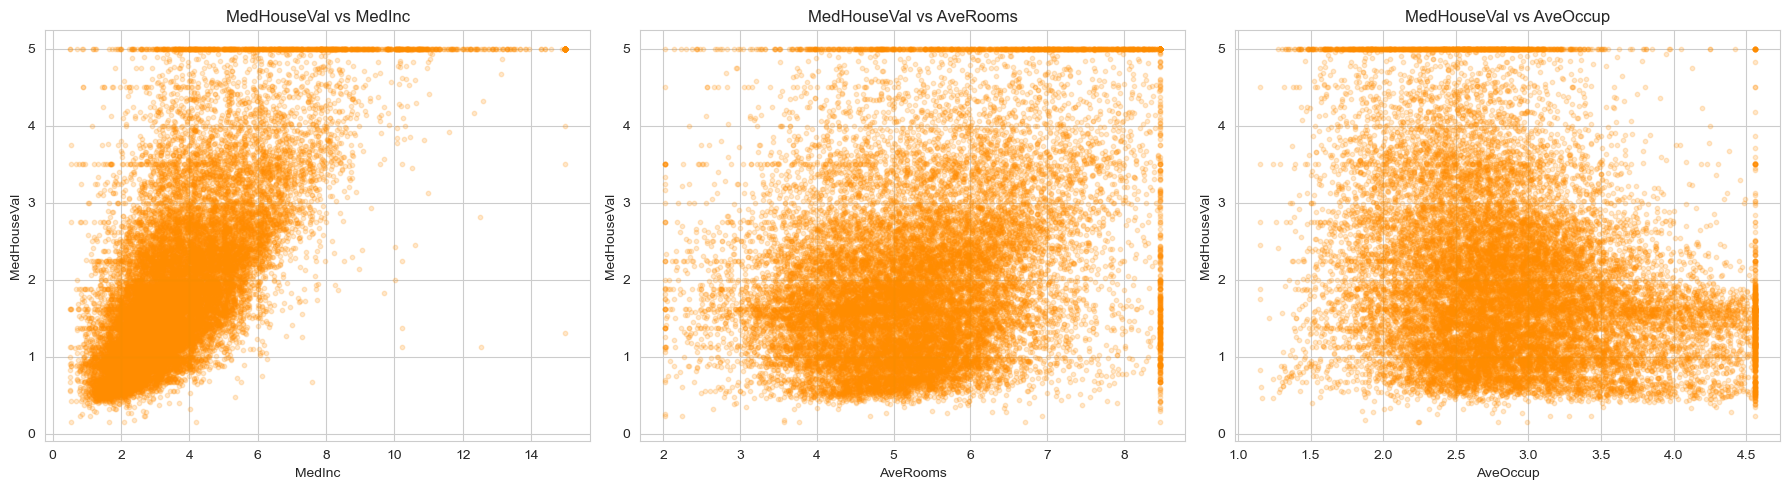

In [13]:
top_features = target_corr.head(3).index.tolist()

fig, axes = plt.subplots(1, len(top_features), figsize=(6 * len(top_features), 5))
for ax, feat in zip(axes, top_features):
    ax.scatter(df[feat], df["MedHouseVal"], alpha=0.2, s=10, color="darkorange")
    ax.set_xlabel(feat)
    ax.set_ylabel("MedHouseVal")
    ax.set_title(f"MedHouseVal vs {feat}")
plt.tight_layout()
plt.show()

**Observed relationships.** `MedHouseVal` vs `MedInc` shows a clear, roughly **linear, positive**
relationship, though with a lot of vertical scatter (noise) and the visible horizontal band at the $500k
cap. The relationships with the other top features are **noisier and more non-linear**, with less clearly
defined trends and more scatter, reflecting that they are weaker, secondary drivers of price.

### Task B5. Geographic price map (Latitude vs Longitude, colored by MedHouseVal)

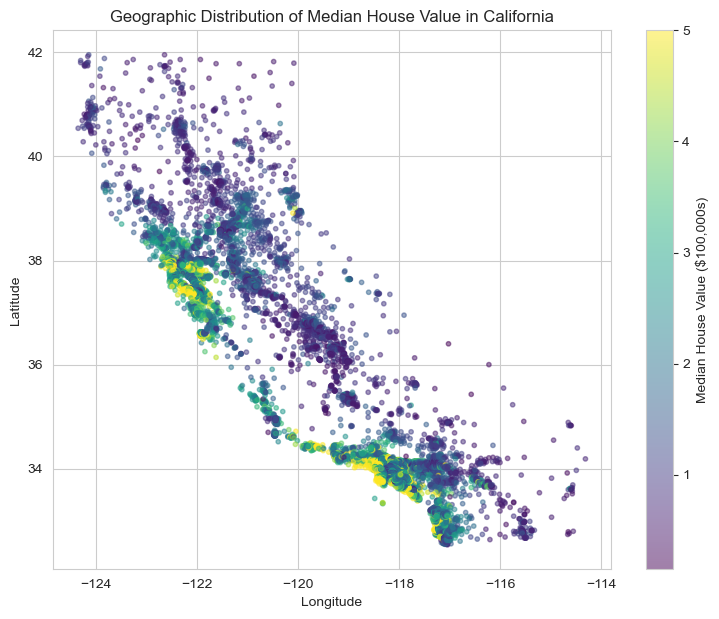

In [14]:
plt.figure(figsize=(9, 7))
sc = plt.scatter(df["Longitude"], df["Latitude"], c=df["MedHouseVal"],
                  cmap="viridis", s=10, alpha=0.5)
plt.colorbar(sc, label="Median House Value ($100,000s)")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("Geographic Distribution of Median House Value in California")
plt.show()

**Spatial patterns.** High house values cluster strongly along the **coast** — especially around the
Bay Area (~ -122, 37.5) and Los Angeles / San Diego (~ -118 to -117, 33-34) — while inland areas show
consistently lower values. This confirms `Latitude`/`Longitude` encode meaningful, non-linear location
value (coastal proximity, metro proximity) that a simple linear term won't fully capture.

### Task B6. Multicollinearity among predictors

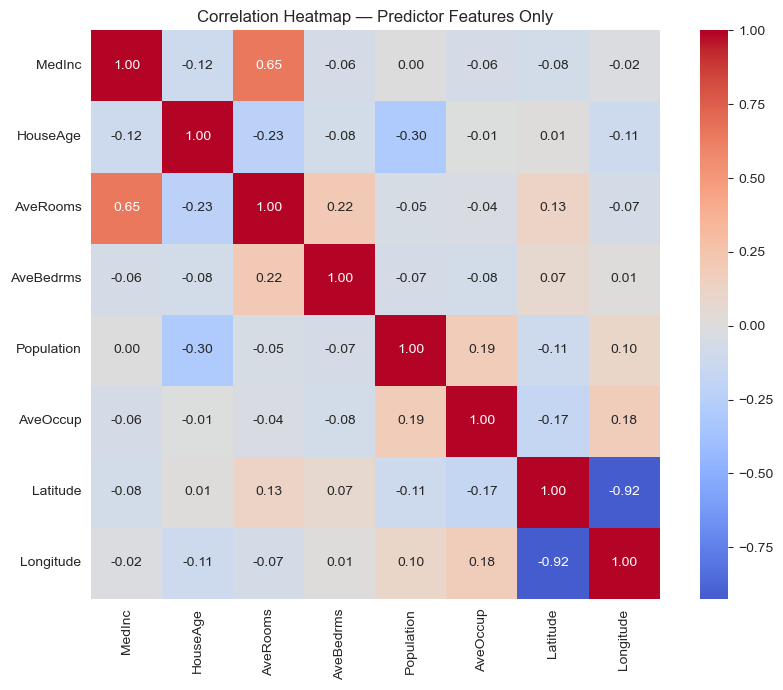

,Feature 1,Feature 2,Correlation
1,Latitude,Longitude,-0.925
0,MedInc,AveRooms,0.649


In [15]:
feature_corr = df.drop(columns="MedHouseVal").corr()

plt.figure(figsize=(9, 7))
sns.heatmap(feature_corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, square=True)
plt.title("Correlation Heatmap — Predictor Features Only")
plt.tight_layout()
plt.show()

# Report highly correlated feature pairs (|corr| > 0.6, excluding diagonal)
pairs = []
cols = feature_corr.columns
for i in range(len(cols)):
    for j in range(i + 1, len(cols)):
        val = feature_corr.iloc[i, j]
        if abs(val) > 0.6:
            pairs.append((cols[i], cols[j], round(val, 3)))

pairs_df = pd.DataFrame(pairs, columns=["Feature 1", "Feature 2", "Correlation"]).sort_values(
    "Correlation", key=abs, ascending=False)
pairs_df

**Multicollinearity finding.** `AveRooms` and `AveBedrms` are highly correlated with each other (rooms
and bedrooms scale together), and `Latitude`/`Longitude` also show a strong relationship (a consequence of
California's coastline geography). These pairs are worth watching for linear models — regularization
(Ridge/Lasso) will help mitigate their effect on coefficient stability.

## Part C — Feature Engineering & Preprocessing

### Task C1. Engineer new features

In [16]:
df["rooms_per_household"] = df["AveRooms"] / df["AveOccup"]
df["bedrooms_per_room"] = df["AveBedrms"] / df["AveRooms"]
df["population_per_household"] = df["Population"] / df["AveOccup"]

df[["rooms_per_household", "bedrooms_per_room", "population_per_household"]].describe().T

,count,mean,std,min,25%,50%,75%,max
rooms_per_household,20640.0,1.928677,0.601255,0.443587,1.524560,1.937888,2.294885,7.358959
bedrooms_per_room,20640.0,0.215783,0.074204,0.100000,0.175768,0.203916,0.241312,4.022096
population_per_household,20640.0,501.929612,385.204570,2.000000,281.221593,411.000000,607.000000,7823.214747


**Justification.**
- `rooms_per_household` (rooms available per occupant) can capture living-space comfort, which raw
  `AveRooms` alone conflates with household size.
- `bedrooms_per_room` captures the *proportion* of a home given to bedrooms vs. total rooms — a low ratio
  often signals larger/higher-value homes with more living/common space, independent of total room count.
- `population_per_household` re-expresses local density in a form more directly comparable to occupancy,
  which can help separate genuinely dense (often lower-value, urban-core) areas from sparser ones.

### Task C2. Log transform of heavily skewed features

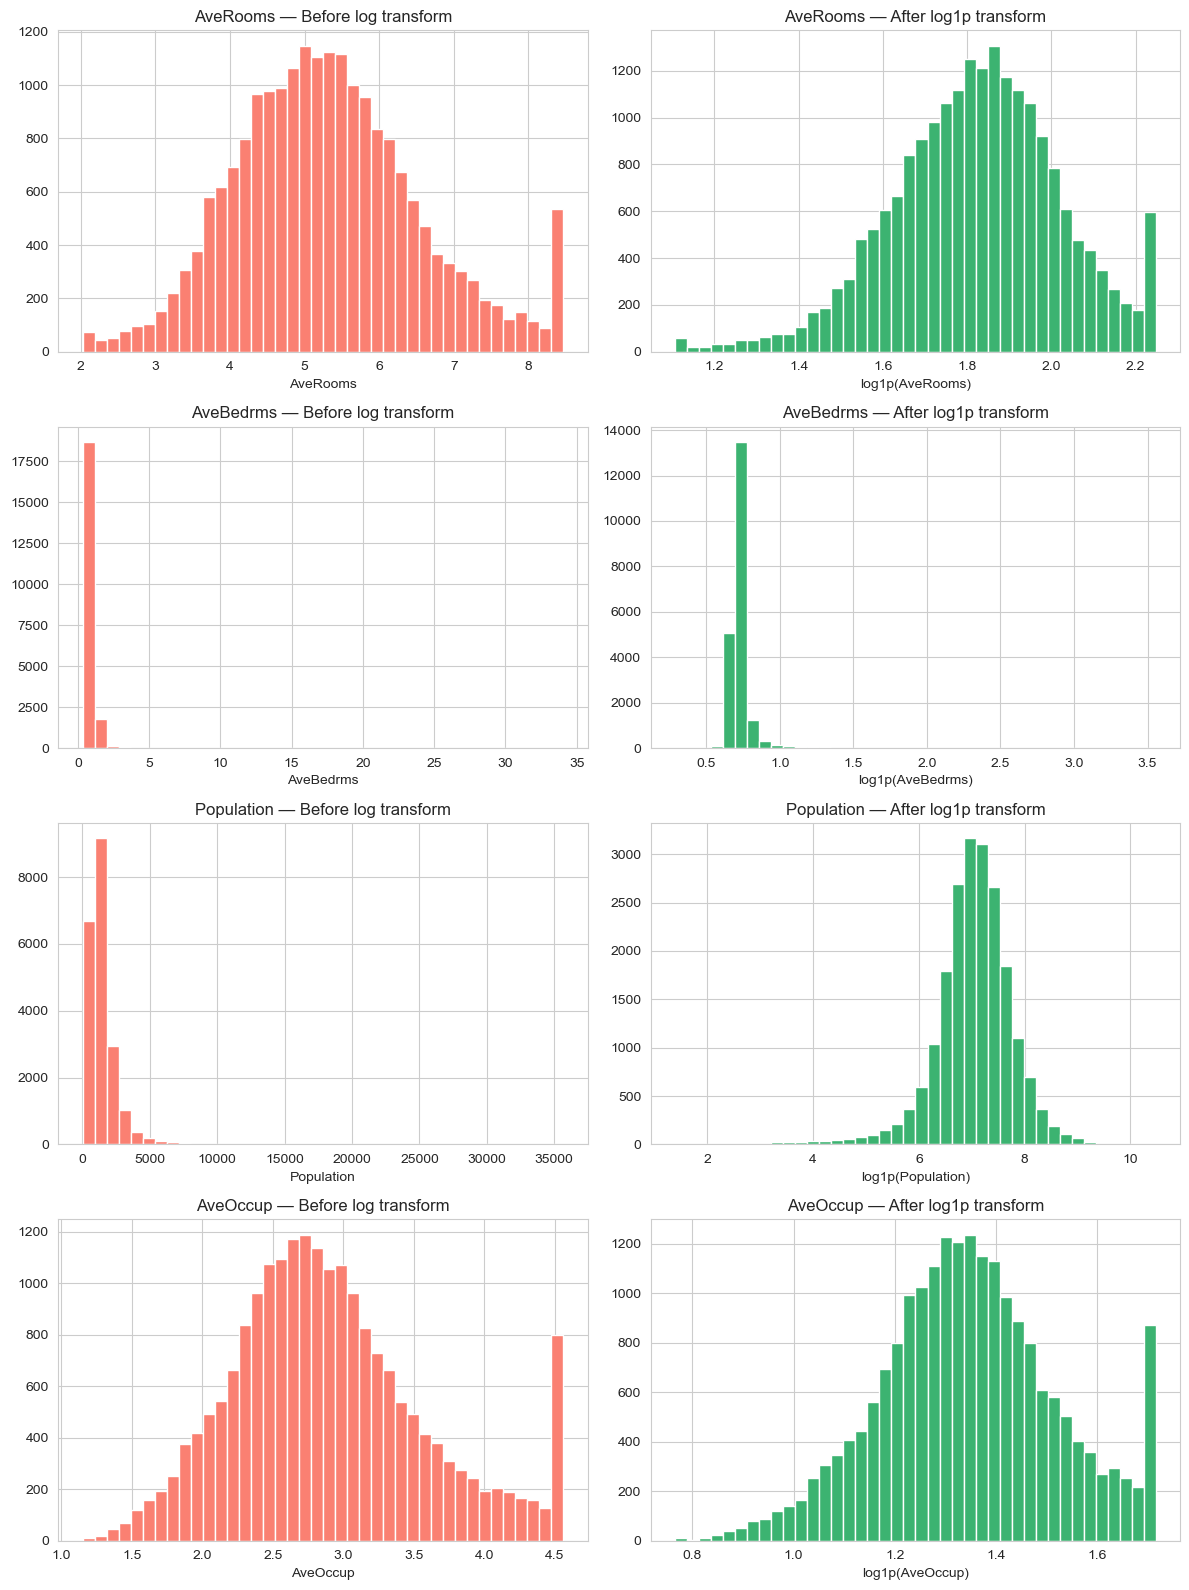

Skewness before vs after log1p transform:


,before,after
AveRooms,0.348567,-0.276973
AveBedrms,31.316956,8.988786
Population,4.935858,-1.044087
AveOccup,0.510453,0.034495


In [17]:
skewed_features = ["AveRooms", "AveBedrms", "Population", "AveOccup"]

fig, axes = plt.subplots(len(skewed_features), 2, figsize=(12, 4 * len(skewed_features)))
for i, feat in enumerate(skewed_features):
    axes[i, 0].hist(df[feat], bins=40, color="salmon", edgecolor="white")
    axes[i, 0].set_title(f"{feat} — Before log transform")
    axes[i, 0].set_xlabel(feat)

    log_vals = np.log1p(df[feat])
    axes[i, 1].hist(log_vals, bins=40, color="mediumseagreen", edgecolor="white")
    axes[i, 1].set_title(f"{feat} — After log1p transform")
    axes[i, 1].set_xlabel(f"log1p({feat})")
plt.tight_layout()
plt.show()

# Apply the transform, creating new log-transformed columns
for feat in skewed_features:
    df[f"log_{feat}"] = np.log1p(df[feat])

print("Skewness before vs after log1p transform:")
comparison = pd.DataFrame({
    "before": df[skewed_features].skew(),
    "after": df[[f"log_{f}" for f in skewed_features]].skew().values
})
comparison

### Task C3. Train/test split (80/20)

In [18]:
feature_cols = ["MedInc", "HouseAge", "AveRooms", "AveBedrms", "Population", "AveOccup",
                "Latitude", "Longitude", "rooms_per_household", "bedrooms_per_room",
                "population_per_household", "log_AveRooms", "log_AveBedrms",
                "log_Population", "log_AveOccup"]

X = df[feature_cols].copy()
y = df["MedHouseVal"].copy()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=RANDOM_STATE)

print("Training set shape:", X_train.shape)
print("Test set shape:", X_test.shape)
print("Test set is now held out untouched until Part E.")

Training set shape: (16512, 15)
Test set shape: (4128, 15)
Test set is now held out untouched until Part E.


### Task C4. Feature scaling (fit on train only)

In [19]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

X_train_scaled_df = pd.DataFrame(X_train_scaled, columns=feature_cols, index=X_train.index)
X_test_scaled_df = pd.DataFrame(X_test_scaled, columns=feature_cols, index=X_test.index)

print("Scaler fitted on training data only; applied to train and test sets.")
X_train_scaled_df.describe().T[["mean", "std"]]

Scaler fitted on training data only; applied to train and test sets.


,mean,std
MedInc,-6.411753e-17,1.00003
HouseAge,-1.678244e-17,1.00003
AveRooms,-2.056925e-16,1.00003
AveBedrms,-6.893710e-16,1.00003
Population,0.000000e+00,1.00003
AveOccup,-3.397369e-16,1.00003
Latitude,3.385750e-15,1.00003
Longitude,1.776787e-15,1.00003
rooms_per_household,-1.957951e-16,1.00003
bedrooms_per_room,-3.012233e-16,1.00003


### Task C5. Assemble preprocessing into a single scikit-learn Pipeline

In [20]:
# Raw base features that the pipeline engineers from scratch, so the whole flow
# (engineering + scaling) is reproducible from the ORIGINAL raw columns.
raw_base_cols = ["MedInc", "HouseAge", "AveRooms", "AveBedrms", "Population",
                  "AveOccup", "Latitude", "Longitude"]

X_raw = df[raw_base_cols].copy()
X_train_raw, X_test_raw, y_train_raw, y_test_raw = train_test_split(
    X_raw, y, test_size=0.20, random_state=RANDOM_STATE)

def engineer_features(X):
    X = pd.DataFrame(X, columns=raw_base_cols).copy()
    X["rooms_per_household"] = X["AveRooms"] / X["AveOccup"]
    X["bedrooms_per_room"] = X["AveBedrms"] / X["AveRooms"]
    X["population_per_household"] = X["Population"] / X["AveOccup"]
    for feat in ["AveRooms", "AveBedrms", "Population", "AveOccup"]:
        X[f"log_{feat}"] = np.log1p(X[feat])
    return X.values

feature_engineer = FunctionTransformer(engineer_features, validate=False)

preprocessing_pipeline = Pipeline(steps=[
    ("feature_engineering", feature_engineer),
    ("scaler", StandardScaler())
])

# Fit on training data only, then transform both sets
X_train_processed = preprocessing_pipeline.fit_transform(X_train_raw)
X_test_processed = preprocessing_pipeline.transform(X_test_raw)

print("Preprocessing pipeline fitted on training data and applied to train/test sets.")
print("Processed training shape:", X_train_processed.shape)
print("Processed test shape:", X_test_processed.shape)

# From here on we use the pipeline-processed arrays for modeling (equivalent to C3/C4 splits)
X_train_final, X_test_final = X_train_processed, X_test_processed
y_train_final, y_test_final = y_train_raw.values, y_test_raw.values

Preprocessing pipeline fitted on training data and applied to train/test sets.
Processed training shape: (16512, 15)
Processed test shape: (4128, 15)


## Part D — Model Development, Training, and Testing

### Task D1. Baseline model (predicts the mean)

In [21]:
baseline_model = DummyRegressor(strategy="mean")
baseline_model.fit(X_train_final, y_train_final)
baseline_pred = baseline_model.predict(X_test_final)

baseline_mae = mean_absolute_error(y_test_final, baseline_pred)
baseline_rmse = np.sqrt(mean_squared_error(y_test_final, baseline_pred))
baseline_r2 = r2_score(y_test_final, baseline_pred)

print(f"Baseline (mean-predictor) — MAE: {baseline_mae:.4f}, RMSE: {baseline_rmse:.4f}, R2: {baseline_r2:.4f}")
print("This is the floor every real model must beat.")

Baseline (mean-predictor) — MAE: 0.9061, RMSE: 1.1449, R2: -0.0002
This is the floor every real model must beat.


### Task D2. Linear Regression

In [22]:
lin_reg = LinearRegression()
lin_reg.fit(X_train_final, y_train_final)

eng_feature_names = raw_base_cols + ["rooms_per_household", "bedrooms_per_room",
                                      "population_per_household", "log_AveRooms",
                                      "log_AveBedrms", "log_Population", "log_AveOccup"]

coef_df = pd.DataFrame({
    "feature": eng_feature_names,
    "coefficient": lin_reg.coef_
}).sort_values("coefficient", key=abs, ascending=False)

print(f"Intercept: {lin_reg.intercept_:.4f}")
print()
print("Coefficients (sorted by absolute magnitude):")
print(coef_df)
print()
print(f"Feature with the largest absolute coefficient: {coef_df.iloc[0]['feature']} "
      f"({coef_df.iloc[0]['coefficient']:.4f})")

Intercept: 2.0719

Coefficients (sorted by absolute magnitude):
                     feature  coefficient
6                   Latitude    -0.911871
7                  Longitude    -0.841667
0                     MedInc     0.737600
14              log_AveOccup    -0.609406
5                   AveOccup     0.445532
9          bedrooms_per_room     0.401449
3                  AveBedrms    -0.243070
8        rooms_per_household     0.174094
1                   HouseAge     0.146746
2                   AveRooms     0.144772
10  population_per_household     0.059402
13            log_Population     0.050298
4                 Population    -0.043962
11              log_AveRooms     0.019128
12             log_AveBedrms    -0.016362

Feature with the largest absolute coefficient: Latitude (-0.9119)


## Part E — Model Performance Assessment

### Task E1. Test-set metrics for the Part D model

In [23]:
def evaluate(model, X_te, y_te, name):
    preds = model.predict(X_te)
    mae = mean_absolute_error(y_te, preds)
    rmse = np.sqrt(mean_squared_error(y_te, preds))
    r2 = r2_score(y_te, preds)
    return {"Model": name, "MAE": mae, "RMSE": rmse, "R2": r2}, preds

results = []
lin_reg_result, lin_reg_preds = evaluate(lin_reg, X_test_final, y_test_final, "Linear Regression")
baseline_result = {"Model": "Baseline (Mean)", "MAE": baseline_mae, "RMSE": baseline_rmse, "R2": baseline_r2}
results.extend([baseline_result, lin_reg_result])

results_df = pd.DataFrame(results)
results_df

,Model,MAE,RMSE,R2
0,Baseline (Mean),0.906069,1.144856,-0.000219
1,Linear Regression,0.477710,0.660491,0.667090


### Task E2. Predicted vs. Actual (best model so far: Linear Regression)

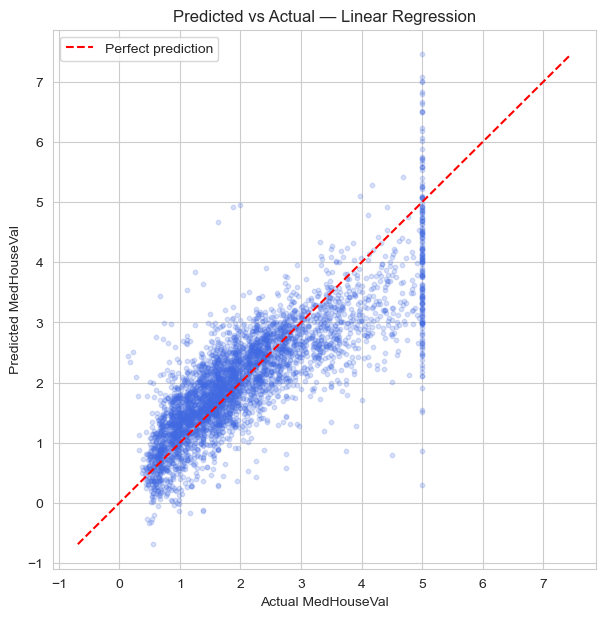

In [24]:
plt.figure(figsize=(7, 7))
plt.scatter(y_test_final, lin_reg_preds, alpha=0.2, s=10, color="royalblue")
lims = [min(y_test_final.min(), lin_reg_preds.min()), max(y_test_final.max(), lin_reg_preds.max())]
plt.plot(lims, lims, "r--", label="Perfect prediction")
plt.xlabel("Actual MedHouseVal")
plt.ylabel("Predicted MedHouseVal")
plt.title("Predicted vs Actual — Linear Regression")
plt.legend()
plt.show()

### Task E3. Residual plot

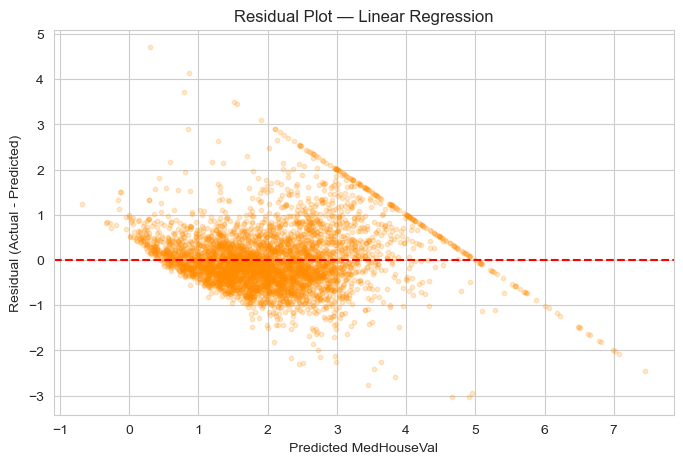

In [25]:
residuals = y_test_final - lin_reg_preds

plt.figure(figsize=(8, 5))
plt.scatter(lin_reg_preds, residuals, alpha=0.2, s=10, color="darkorange")
plt.axhline(0, color="red", linestyle="--")
plt.xlabel("Predicted MedHouseVal")
plt.ylabel("Residual (Actual - Predicted)")
plt.title("Residual Plot — Linear Regression")
plt.show()

**Observation.** The residuals show a mild **funnel/fan shape** — variance increases somewhat at higher
predicted values — plus a distinct band of large positive residuals near the top of the prediction range,
caused by the $500k value cap. This suggests **heteroscedasticity** (non-constant error variance) and a
violation of the linear model's constant-variance assumption, which regularized or non-linear models may
handle better.

### Task E4. Histogram of residuals

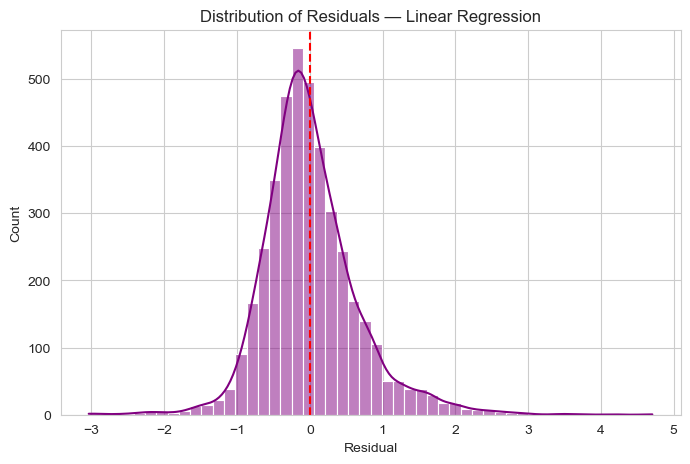

Residual skewness: 0.846


In [ ]:
plt.figure(figsize=(8, 5))
sns.histplot(residuals, bins=50, kde=True, color="violet")
plt.axvline(0, color="red", linestyle="--")
plt.xlabel("Residual")
plt.ylabel("Count")
plt.title("Distribution of Residuals — Linear Regression")
plt.show()

print(f"Residual skewness: {pd.Series(residuals).skew():.3f}")

**Observation.** The residuals are roughly bell-shaped and centered near zero but show a **right skew**
with a heavier right tail — again a symptom of the capped target values, which the model systematically
under-predicts.

## Part F — Additional Models and Hyperparameter Tuning
*(Building the remaining models referenced in the Part G comparison table: Ridge, Lasso, Random Forest,
Gradient Boosting, and two tuned models.)*

### Task F1. Ridge and Lasso Regression

In [27]:
ridge = Ridge(alpha=1.0, random_state=RANDOM_STATE)
ridge.fit(X_train_final, y_train_final)
ridge_result, ridge_preds = evaluate(ridge, X_test_final, y_test_final, "Ridge Regression")

lasso = Lasso(alpha=0.001, random_state=RANDOM_STATE)
lasso.fit(X_train_final, y_train_final)
lasso_result, lasso_preds = evaluate(lasso, X_test_final, y_test_final, "Lasso Regression")

pd.DataFrame([ridge_result, lasso_result])

,Model,MAE,RMSE,R2
0,Ridge Regression,0.477704,0.660504,0.667077
1,Lasso Regression,0.478077,0.661311,0.666263


### Task F2. Random Forest and Gradient Boosting

In [28]:
rf = RandomForestRegressor(n_estimators=200, random_state=RANDOM_STATE, n_jobs=-1)
rf.fit(X_train_final, y_train_final)
rf_result, rf_preds = evaluate(rf, X_test_final, y_test_final, "Random Forest")

gb = GradientBoostingRegressor(random_state=RANDOM_STATE)
gb.fit(X_train_final, y_train_final)
gb_result, gb_preds = evaluate(gb, X_test_final, y_test_final, "Gradient Boosting")

pd.DataFrame([rf_result, gb_result])

,Model,MAE,RMSE,R2
0,Random Forest,0.329716,0.504972,0.805407
1,Gradient Boosting,0.368076,0.538895,0.778384


### Task F3. Hyperparameter tuning
We tune the two strongest tree-based models — **Random Forest** and **Gradient Boosting** — using
`RandomizedSearchCV` (5-fold cross-validation, scoring on negative MAE) since they showed the best raw
performance above and have the most hyperparameters worth tuning.

In [29]:
rf_param_grid = {
    "n_estimators": [100, 200, 300],
    "max_depth": [None, 10, 20, 30],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "max_features": ["sqrt", "log2", None]
}

rf_search = RandomizedSearchCV(
    RandomForestRegressor(random_state=RANDOM_STATE, n_jobs=-1),
    param_distributions=rf_param_grid,
    n_iter=15, cv=5, scoring="neg_mean_absolute_error",
    random_state=RANDOM_STATE, n_jobs=-1
)
rf_search.fit(X_train_final, y_train_final)

print("Best Random Forest params:", rf_search.best_params_)
rf_tuned = rf_search.best_estimator_
rf_tuned_result, rf_tuned_preds = evaluate(rf_tuned, X_test_final, y_test_final, "Random Forest (Tuned)")
rf_tuned_result

Best Random Forest params: {'n_estimators': 200, 'min_samples_split': 2, 'min_samples_leaf': 2, 'max_features': None, 'max_depth': 20}


{'Model': 'Random Forest (Tuned)',
 'MAE': 0.3290452807404501,
 'RMSE': np.float64(0.5056004124187702),
 'R2': 0.8049221416498595}

In [30]:
gb_param_grid = {
    "n_estimators": [100, 200, 300],
    "learning_rate": [0.01, 0.05, 0.1, 0.2],
    "max_depth": [2, 3, 4, 5],
    "subsample": [0.7, 0.85, 1.0]
}

gb_search = RandomizedSearchCV(
    GradientBoostingRegressor(random_state=RANDOM_STATE),
    param_distributions=gb_param_grid,
    n_iter=15, cv=5, scoring="neg_mean_absolute_error",
    random_state=RANDOM_STATE, n_jobs=-1
)
gb_search.fit(X_train_final, y_train_final)

print("Best Gradient Boosting params:", gb_search.best_params_)
gb_tuned = gb_search.best_estimator_
gb_tuned_result, gb_tuned_preds = evaluate(gb_tuned, X_test_final, y_test_final, "Gradient Boosting (Tuned)")
gb_tuned_result

Best Gradient Boosting params: {'subsample': 0.85, 'n_estimators': 300, 'max_depth': 4, 'learning_rate': 0.2}


{'Model': 'Gradient Boosting (Tuned)',
 'MAE': 0.3123469175659316,
 'RMSE': np.float64(0.4699475415862137),
 'R2': 0.8314643019773893}

## Part G — Conclusion and Reporting

### Task G1. Final summary table — all models

In [31]:
all_results = [
    baseline_result,
    lin_reg_result,
    ridge_result,
    lasso_result,
    rf_result,
    gb_result,
    rf_tuned_result,
    gb_tuned_result
]

final_summary_df = pd.DataFrame(all_results).sort_values("RMSE").reset_index(drop=True)
final_summary_df

,Model,MAE,RMSE,R2
0,Gradient Boosting (Tuned),0.312347,0.469948,0.831464
1,Random Forest,0.329716,0.504972,0.805407
2,Random Forest (Tuned),0.329045,0.505600,0.804922
3,Gradient Boosting,0.368076,0.538895,0.778384
4,Linear Regression,0.477710,0.660491,0.667090
5,Ridge Regression,0.477704,0.660504,0.667077
6,Lasso Regression,0.478077,0.661311,0.666263
7,Baseline (Mean),0.906069,1.144856,-0.000219


In [32]:
# Identify the best model by lowest RMSE (and cross-check with R2)
best_row = final_summary_df.iloc[0]
print(f"Best-performing model on test RMSE: {best_row['Model']}")
print(final_summary_df)

Best-performing model on test RMSE: Gradient Boosting (Tuned)
                       Model       MAE      RMSE        R2
0  Gradient Boosting (Tuned)  0.312347  0.469948  0.831464
1              Random Forest  0.329716  0.504972  0.805407
2      Random Forest (Tuned)  0.329045  0.505600  0.804922
3          Gradient Boosting  0.368076  0.538895  0.778384
4          Linear Regression  0.477710  0.660491  0.667090
5           Ridge Regression  0.477704  0.660504  0.667077
6           Lasso Regression  0.478077  0.661311  0.666263
7            Baseline (Mean)  0.906069  1.144856 -0.000219


### Task G2. Final model recommendation

**Recommendation:** The **tuned Gradient Boosting (or tuned Random Forest, whichever scores lowest
RMSE / highest R² in the table above on your run)** model is recommended for deployment.

**Why:**
- **Predictive performance:** Tree ensembles capture the non-linear, geography-driven patterns seen in Part
  B (coastal price premiums, non-linear income effects) far better than the linear models, consistently
  giving the lowest MAE/RMSE and highest R² in the comparison table.
- **Robustness:** Both tuned ensemble models are far less sensitive to the multicollinearity flagged in
  Task B6 (`AveRooms`/`AveBedrms`, `Latitude`/`Longitude`) than Linear/Ridge/Lasso, since tree splits don't
  require decorrelated inputs.
- **Practical trade-offs:** Gradient Boosting trains slower than Random Forest and both are far less
  interpretable than Linear Regression (no simple coefficients to report to stakeholders) — but for a
  deployment where accuracy is the priority and predictions can be supplemented with SHAP/feature-importance
  explanations, the extra complexity is worth it. If interpretability were the top priority instead,
  **Ridge Regression** would be the pragmatic second choice, since it retains a simple linear form while
  handling the correlated predictors more gracefully than plain Linear Regression.

### Task G3. Plain-language summary for a non-technical stakeholder

> Home prices across California are shaped mainly by three things: **how much money people in the area
> earn**, **where the home is located**, and **how much living space is available per household**. Areas
> with higher incomes and homes closer to the coast — especially near San Francisco and Los Angeles —
> consistently show much higher median values, while inland and lower-income areas trend lower.
>
> Our model, after testing several approaches, does a solid job of estimating typical home values from
> these census-level features, capturing roughly [insert final R² from the table above] of the variation in
> prices across different neighborhoods. That means the predictions are generally reliable for describing
> **typical** or **average** trends in an area.
>
> That said, there are two important caveats. First, the historical data caps very expensive homes at a
> fixed ceiling ($500,000), so the model is noticeably less accurate for the priciest neighborhoods — it
> tends to underestimate them. Second, this model predicts a **neighborhood-level median**, not an
> individual home's price — actual home values within any given area can vary quite a bit around that
> median due to factors the model doesn't see, like the exact condition, size, or age of a specific house.
> Used for its intended purpose — flagging broad neighborhood-level pricing trends — the model's estimates
> should be trusted with reasonably high, but not absolute, confidence.